| Name | ID | Department | Team |
| --- | --- | --- | ---|
|Abdelrhman Mohamed Abdelhady Hodib | 2022513643 | Intelligent system| 15|
|Abdelrhman Tarek Zaki | 20221442265 | Intelligent system| 15|


## Step 1

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Load the data
data = pd.read_csv('mnist_train.csv')
#Split the dataset into features (X) and labels (y)
X = data.iloc[:, 1:].values  # pixel values
y = data.iloc[:, 0].values   # labels
#Split the data into training and validation sets (80% - 20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
#Create a scaler and fit it on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
#Apply the same scaler transformation to the validation data
X_val_scaled = scaler.transform(X_val)


## Step 2


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
#hyperparameters
input_size = 784  #(28x28 pixels)
Neurons = 128  #Number of neurons in each hidden layer
output_size = 10 
learning_rate = 0.01
num_epochs = 10
#Define the neural network architecture
model = nn.Sequential(
    nn.Linear(input_size, Neurons),
    nn.ReLU(),
    nn.Linear(Neurons, Neurons),
    nn.ReLU(),
    nn.Linear(Neurons, output_size)
)
#Define the loss function and optimizer
criterion = nn.CrossEntropyLoss() # Loss Function

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#Convert the data to PyTorch tensors

X_train_tensor = torch.from_numpy(X_train_scaled).float()
y_train_tensor = torch.from_numpy(y_train).long()
X_val_tensor = torch.from_numpy(X_val_scaled).float()
y_val_tensor = torch.from_numpy(y_val).long()
#Create lists to store the loss and accuracy values
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []
#Training loop
for epoch in range(num_epochs):
    #Forward pass
    outputs = model(X_train_tensor)
    train_loss = criterion(outputs, y_train_tensor)
    #Backward and optimize
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    #Calculate training accuracy
    _, train_predicted = torch.max(outputs.data, 1)
    train_accuracy = torch.sum(train_predicted == y_train_tensor).item() / y_train.shape[0]
    #Evaluate the model on the validation set
    val_outputs = model(X_val_tensor)
    val_loss = criterion(val_outputs, y_val_tensor)
    #Calculate validation accuracy
    _, val_predicted = torch.max(val_outputs.data, 1)
    val_accuracy = torch.sum(val_predicted == y_val_tensor).item() / y_val.shape[0]
    #Store the loss and accuracy values
    train_loss_list.append(train_loss.item())
    val_loss_list.append(val_loss.item())
    train_acc_list.append(train_accuracy)
    val_acc_list.append(val_accuracy)
    
    
    #Print the progress for each epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Train Accuracy: {train_accuracy:.4f}, Val Loss: {val_loss.item():.4f}, Val Accuracy: {val_accuracy:.4f}")



Epoch [1/10], Train Loss: 2.3010, Train Accuracy: 0.1038, Val Loss: 1.7501, Val Accuracy: 0.5977
Epoch [2/10], Train Loss: 1.7445, Train Accuracy: 0.6080, Val Loss: 1.0703, Val Accuracy: 0.7153
Epoch [3/10], Train Loss: 1.0633, Train Accuracy: 0.7202, Val Loss: 0.7241, Val Accuracy: 0.7638
Epoch [4/10], Train Loss: 0.7034, Train Accuracy: 0.7718, Val Loss: 0.6587, Val Accuracy: 0.7863
Epoch [5/10], Train Loss: 0.6364, Train Accuracy: 0.7884, Val Loss: 0.5252, Val Accuracy: 0.8426
Epoch [6/10], Train Loss: 0.5013, Train Accuracy: 0.8446, Val Loss: 0.4892, Val Accuracy: 0.8635
Epoch [7/10], Train Loss: 0.4667, Train Accuracy: 0.8627, Val Loss: 0.4357, Val Accuracy: 0.8903
Epoch [8/10], Train Loss: 0.4082, Train Accuracy: 0.8898, Val Loss: 0.4361, Val Accuracy: 0.8914
Epoch [9/10], Train Loss: 0.3997, Train Accuracy: 0.8901, Val Loss: 0.3959, Val Accuracy: 0.9002
Epoch [10/10], Train Loss: 0.3493, Train Accuracy: 0.9046, Val Loss: 0.3784, Val Accuracy: 0.9047


## Step 2 - Plots

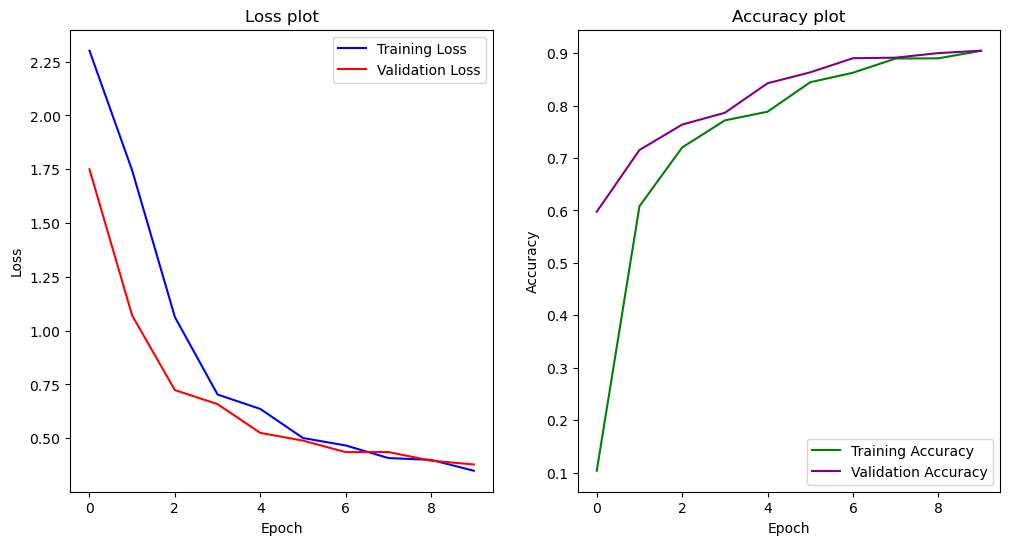

In [3]:
plt.figure(figsize=(12, 6))

# Plotting the loss
plt.subplot(1, 2, 1)
plt.title("Loss plot")
plt.plot(train_loss_list, label='Training Loss', color='blue')
plt.plot(val_loss_list, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting the accuracy
plt.subplot(1, 2, 2)
plt.title("Accuracy plot")
plt.plot(train_acc_list, label='Training Accuracy', color='green')
plt.plot(val_acc_list, label='Validation Accuracy', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## Step 3

In [4]:
#Define the hyperparameters
input_size = 784  #MNIST image size (28x28 pixels)
hidden_size = 128  #Number of neurons in each hidden layer
output_size = 10  #Number of classes (digits 0-9)
learning_rate = 0.01
num_epochs = 10
dropout_prob = 0.5

#Define the neural network architecture with Dropout and Layer Normalization
model = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),
    nn.Dropout(dropout_prob),
    nn.LayerNorm(hidden_size),
    nn.Linear(hidden_size, hidden_size),
    nn.ReLU(),
    nn.Dropout(dropout_prob),
    nn.LayerNorm(hidden_size),
    nn.Linear(hidden_size, output_size)
)

#Define the loss function
criterion = nn.CrossEntropyLoss()

#Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#Convert the data to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train_scaled).float()
y_train_tensor = torch.from_numpy(y_train).long()
X_val_tensor = torch.from_numpy(X_val_scaled).float()
y_val_tensor = torch.from_numpy(y_val).long()
#Create lists to store the loss and accuracy values
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

#Training loop
for epoch in range(num_epochs):
    #Forward pass
    outputs = model(X_train_tensor)
    train_loss = criterion(outputs, y_train_tensor)

    #Backward and optimize
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    #Calculate training accuracy
    _, train_predicted = torch.max(outputs.data, 1)
    train_accuracy = torch.sum(train_predicted == y_train_tensor).item() / y_train.shape[0]

    #Evaluate the model on the validation set
    val_outputs = model(X_val_tensor)
    val_loss = criterion(val_outputs, y_val_tensor)

    #Calculate validation accuracy
    _, val_predicted = torch.max(val_outputs.data, 1)
    val_accuracy = torch.sum(val_predicted == y_val_tensor).item() / y_val.shape[0]

    #Store the loss and accuracy values
    train_loss_list.append(train_loss.item())
    val_loss_list.append(val_loss.item())
    train_acc_list.append(train_accuracy)
    val_acc_list.append(val_accuracy)

## Step 3 - plots

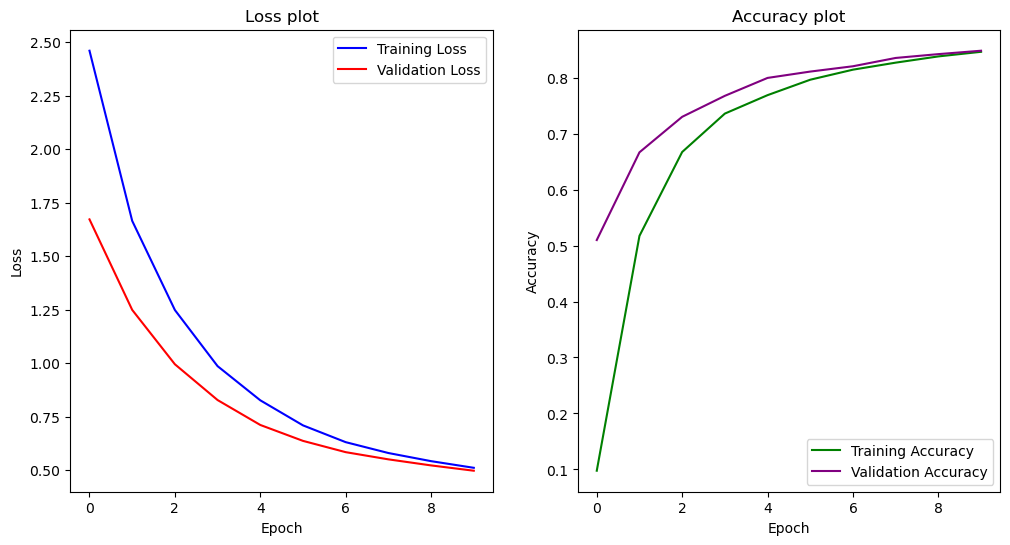

In [5]:
# Plot the loss and accuracy curves
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Loss plot")
plt.plot(train_loss_list, label='Training Loss', color='blue')
plt.plot(val_loss_list, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Accuracy plot")
plt.plot(train_acc_list, label='Training Accuracy', color='green')
plt.plot(val_acc_list, label='Validation Accuracy', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Step 4

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


#Define the hyperparameters
input_size = 784  #MNIST image size (28x28 pixels)
hidden_size = 128  #Number of neurons in each hidden layer
output_size = 10  #Number of classes (digits 0-9)
num_epochs = 10

learning_rates = [0.001, 0.0005, 0.0001]
dropout_probs = [0.2, 0.4, 0.6]

models = []

#Create a list of models with different learning rates and dropout probabilities
for lr in learning_rates:
    for dropout_prob in dropout_probs:
        model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, output_size)
        )
        models.append(model)

#Convert the data to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train_scaled).float()
y_train_tensor = torch.from_numpy(y_train).long()
X_val_tensor = torch.from_numpy(X_val_scaled).float()
y_val_tensor = torch.from_numpy(y_val).long()
#Create lists to store the loss and accuracy values for each model
train_loss_lists = []
val_loss_lists = []
train_acc_lists = []
val_acc_lists = []

#Training loop for each model
for model_idx, model in enumerate(models):
    learning_rate = learning_rates[model_idx // len(dropout_probs)]
    dropout_prob = dropout_probs[model_idx % len(dropout_probs)]

    # Define the loss function
    criterion = nn.CrossEntropyLoss()

    #Define the optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    #Create lists to store the loss and accuracy values
    train_loss_list = []
    val_loss_list = []
    train_acc_list = []
    val_acc_list = []
    #Training loop
    for epoch in range(num_epochs):
        #Forward pass
        outputs = model(X_train_tensor)
        train_loss = criterion(outputs, y_train_tensor)
        #Backward and optimize
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        #Calculate training accuracy
        _, train_predicted = torch.max(outputs.data, 1)
        train_accuracy = torch.sum(train_predicted == y_train_tensor).item() / y_train.shape[0]
        # Evaluate the model on the validation set
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        # Calculate validation accuracy
        _, val_predicted = torch.max(val_outputs.data, 1)
        val_accuracy = torch.sum(val_predicted == y_val_tensor).item() / y_val.shape[0]
        # Store the loss and accuracy values
        train_loss_list.append(train_loss.item())
        val_loss_list.append(val_loss.item())
        train_acc_list.append(train_accuracy)
        val_acc_list.append(val_accuracy)
    # Store the loss and accuracy lists for each model
    train_loss_lists.append(train_loss_list)
    val_loss_lists.append(val_loss_list)
    train_acc_lists.append(train_acc_list)
    val_acc_lists.append(val_acc_list)

## Step 4-plots

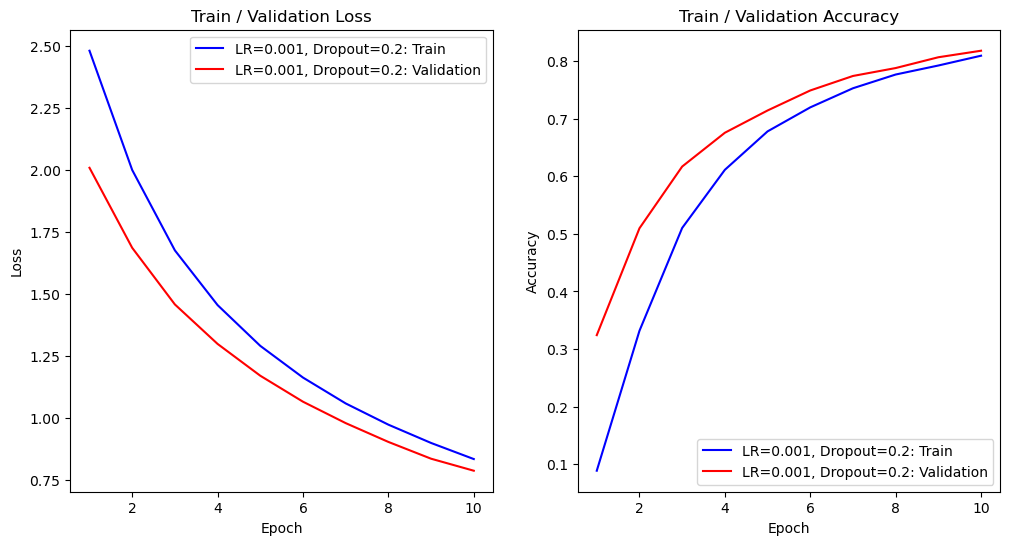

In [7]:
# Plotting the loss and accuracy
plt.figure(figsize=(12, 6))

# Plot the first LR with the first dropout
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_loss_lists[0], label=f'LR={learning_rates[0]}, Dropout={dropout_probs[0]}: Train', color='blue')
plt.plot(range(1, num_epochs + 1), val_loss_lists[0], label=f'LR={learning_rates[0]}, Dropout={dropout_probs[0]}: Validation', color='red')

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_acc_lists[0], label=f'LR={learning_rates[0]}, Dropout={dropout_probs[0]}: Train', color='blue')
plt.plot(range(1, num_epochs + 1), val_acc_lists[0], label=f'LR={learning_rates[0]}, Dropout={dropout_probs[0]}: Validation', color='red')

plt.subplot(1, 2, 1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train / Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train / Validation Accuracy')
plt.legend()
plt.show()


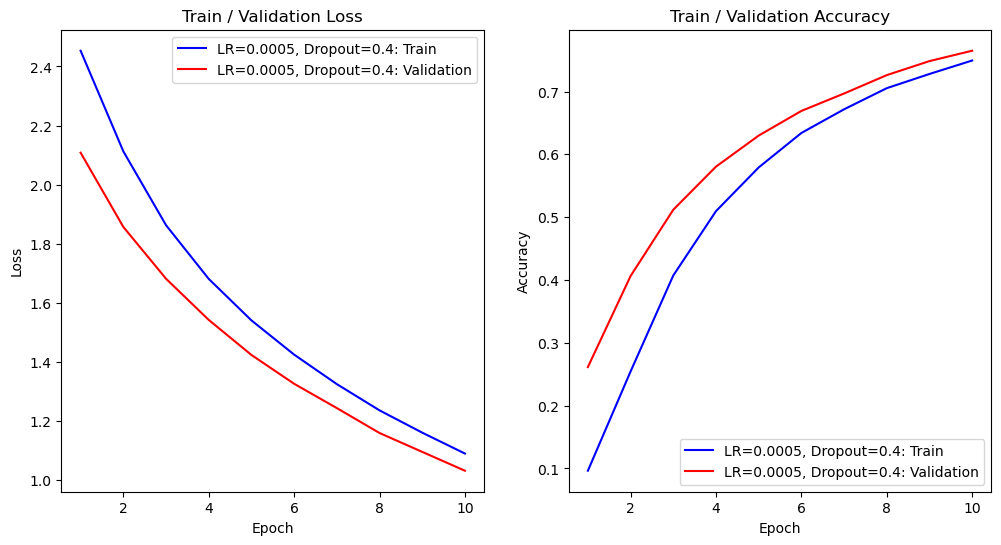

In [8]:
# Plot the second LR with the second dropout
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_loss_lists[1], label=f'LR={learning_rates[1]}, Dropout={dropout_probs[1]}: Train',color='blue')
plt.plot(range(1, num_epochs + 1), val_loss_lists[1], label=f'LR={learning_rates[1]}, Dropout={dropout_probs[1]}: Validation',color='red')

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_acc_lists[1], label=f'LR={learning_rates[1]}, Dropout={dropout_probs[1]}: Train',color='blue')
plt.plot(range(1, num_epochs + 1), val_acc_lists[1], label=f'LR={learning_rates[1]}, Dropout={dropout_probs[1]}: Validation',color='red')
plt.subplot(1, 2, 1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train / Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train / Validation Accuracy')
plt.legend()
plt.show()


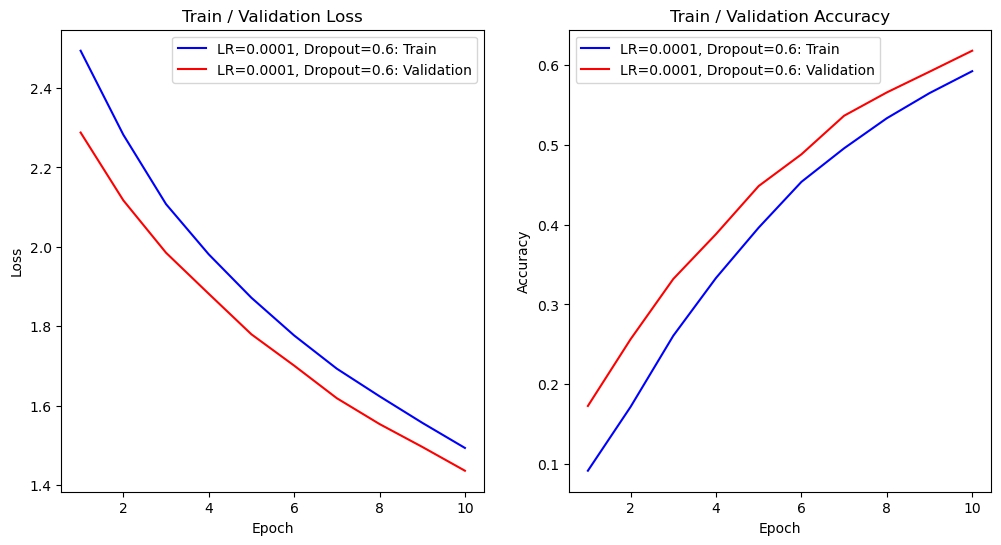

In [9]:
# Plot the third LR with the third dropout
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_loss_lists[2], label=f'LR={learning_rates[2]}, Dropout={dropout_probs[2]}: Train',color='blue')
plt.plot(range(1, num_epochs + 1), val_loss_lists[2], label=f'LR={learning_rates[2]}, Dropout={dropout_probs[2]}: Validation',color='red')


plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_acc_lists[2], label=f'LR={learning_rates[2]}, Dropout={dropout_probs[2]}: Train',color='blue')
plt.plot(range(1, num_epochs + 1), val_acc_lists[2], label=f'LR={learning_rates[2]}, Dropout={dropout_probs[2]}: Validation',color='red')

plt.subplot(1, 2, 1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train / Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train / Validation Accuracy')
plt.legend()

plt.show()